<a href="https://colab.research.google.com/github/deltorobarba/science/blob/main/science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="blue">**Science**</font>

<img src="https://raw.githubusercontent.com/deltorobarba/science/main/nature.JPG" alt="science">


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# @title IBM Quantum Computing

!pip install qiskit qiskit-ibm-runtime qiskit-aer qiskit[visualization] -q
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import userdata
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorSampler as LocalSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from IPython.display import display, Markdown

In [ ]:
# 1. Connect to IBM Quantum Service
  # https://eu-de.quantum.cloud.ibm.com/computers
  # https://eu-de.quantum.cloud.ibm.com/docs/de/guides/qpu-information

print("✅ Connect to IBM Quantum")
api_token = userdata.get('ibm-quantum')
service = QiskitRuntimeService(channel='ibm_quantum_platform', token=api_token)

print("\n✅ List of all backends")
available_backends = service.backends()
print("Available Quantum Backends:")
for b in available_backends:
    print(f"- {b.name} ({b.num_qubits} qubits)")

print("\n✅ Select quantum backend")
#backend = service.backend('ibm_strasbourg') # Choose directly
backend = service.least_busy(simulator=False, operational=True) # Choose automatically
print(f"✅ Selected backend: {backend.name} with {backend.num_qubits} qubits") #backend.target.operation_names
print(f"Backend Operations: {backend.target.operation_names}")

✅ Connect to IBM Quantum


qiskit_runtime_service._discover_account:WARNING:2026-09-11 14:49:32,121: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-09-11 14:49:36,744: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (pay-as-you-go), the available account instances are: einstein. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-09-11 14:49:36,749: Loading instance: einstein, plan: pay-as-you-go



✅ List of all backends
Available Quantum Backends:
- ibm_aachen (156 qubits)

✅ Select quantum backend


qiskit_runtime_service.backends:WARNING:2026-09-11 14:49:38,890: Loading instance: einstein, plan: pay-as-you-go
qiskit_runtime_service.backends:WARNING:2026-09-11 14:49:39,218: Using instance: einstein, plan: pay-as-you-go


✅ Selected backend: ibm_aachen with 156 qubits
Backend Operations: dict_keys(['x', 'delay', 'reset_2', 'xslow', 'measure_reset_2', 'sx', 'measure_reset', 'rz', 'if_else', 'measure_2', 'reset', 'id', 'measure', 'cz'])


<font color="blue">*Use Case: Two-Qubit Entangled [Bell State](https://en.wikipedia.org/wiki/Bell_state) Preparation $|\Phi^+\rangle$*

* Start mit zwei Qubits, $q_0$ und $q_1$, beide initialisiert auf $|0\rangle$, ergibt **$|00\rangle$**.

* Hadamard-Gate versetzt $q_0$ in eine **Superposition**, gleich wahrscheinlich $|0\rangle$ oder $|1\rangle$.
  * Hadamard auf $q_0$: $|00\rangle \xrightarrow{H \otimes I} \left(\frac{|0\rangle + |1\rangle}{\sqrt{2}}\right) \otimes |0\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |10\rangle)$

* CNOT-Gate zur **Verschränkung** ($q_0$ = Control, $q_1$ = Target):
  * $\frac{1}{\sqrt{2}}(|00\rangle + |10\rangle) \xrightarrow{\text{CNOT}} \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle) = |\Phi^+\rangle$

Dieser Zustand $|\Phi^+\rangle$ ist maximal verschränkt: Messung von $q_0$ legt $q_1$ sofort fest, '00' und '11' je mit $\mathbf{50\%}$ Wahrscheinlichkeit.

*Hinweis zur Bit-Reihenfolge:* Qiskit ordnet die Bits im Classical Register mit Qubit 0 als **niedrigstwertigem** (rechten) Bit — bei diesem symmetrischen Bell-State (00/11) ändert das aber nichts am Ergebnis.

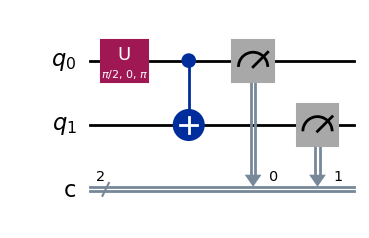

In [ ]:
# 2. Quantum Circuit: Bell State Preparation
  # https://eu-de.quantum.cloud.ibm.com/docs/de/tutorials
qc = QuantumCircuit(2, 2)
qc.h(0)     # Superposition
qc.cx(0, 1) # Entanglement. Test also with swap to see decomposition
qc.measure([0, 1], [0, 1])
#display(qc.draw("mpl"))
qc.decompose().draw("mpl")


Transpiled Circuit for ibm_aachen:


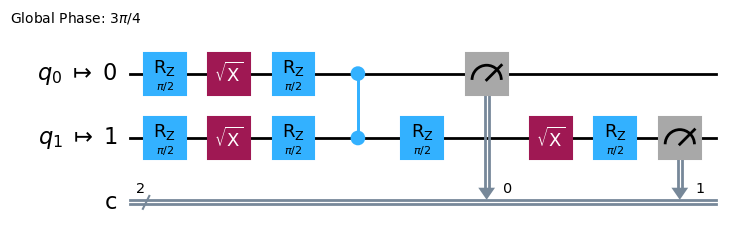

In [ ]:
# 3. Transpile circuit (Minimize number of SWAP operations and use most well-calibrated qubits)
  # https://quantum.cloud.ibm.com/docs/en/guides/transpile#instruction-set-architecture
  # https://quantum.cloud.ibm.com/docs/en/guides/transpiler-stages

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)
print(f"\nTranspiled Circuit for {backend.name}:")
display(isa_circuit.draw("mpl"))

In [ ]:
# 4. Local noiseless simulation
print("\n✅ Local noiseless simulation")
shots = 100
local_sampler = LocalSampler()
local_job = local_sampler.run(pubs=[(qc,)], shots=shots)
local_result = local_job.result()
local_counts = local_result[0].data.c.get_counts()
print(local_counts)
with open('noiseless_result.pkl', 'wb') as f:
    pickle.dump(local_counts, f)


✅ Local noiseless simulation
{'11': 52, '00': 48}


In [ ]:
# 5. Noisy simulation
print("\n✅ Noisy simulation")
noisy_backend = AerSimulator.from_backend(backend)
pm_noisy = generate_preset_pass_manager(backend=noisy_backend, optimization_level=1)
noisy_isa_circuit = pm_noisy.run(qc)
noisy_job = noisy_backend.run(noisy_isa_circuit, shots=shots)
noisy_result = noisy_job.result()
noisy_counts = noisy_result.get_counts()
print(noisy_counts)
with open('noisy_result.pkl', 'wb') as f:
    pickle.dump(noisy_counts, f)


✅ Noisy simulation
{'01': 3, '00': 56, '11': 41}



✅ Run job on IBM quantum computer

Submitting job to ibm_aachen...
Job submitted successfully! Job ID: dai1b1e0csts73fm5ung

✅ Job Status
QUEUED

✅ Job metrics
{'caller': 'qiskit_ibm_runtime~sampler.py', 'qiskit_version': 'qiskit_ibm_runtime-0.49.0,qiskit-2.5.2*,qiskit_aer-0.17.2', 'timestamps': {'created': '2026-09-11T14:51:49.784399Z', 'finished': None, 'running': None}}

Measurement Results (Counts):
{'11': 54, '00': 42, '01': 2, '10': 2}


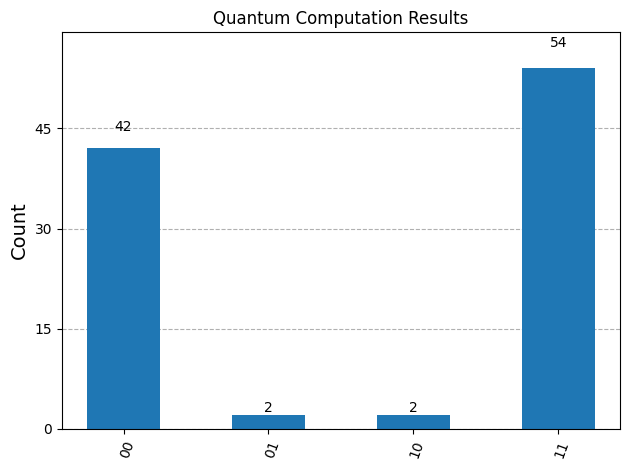

In [ ]:
# 6. Run job on IBM quantum computer ⚠️
  # https://eu-de.quantum.cloud.ibm.com/workloads

print("\n✅ Run job on IBM quantum computer")
sampler = Sampler(mode=backend)
print(f"\nSubmitting job to {backend.name}...")
job = sampler.run(pubs=[(isa_circuit,)], shots=shots)
print(f"Job submitted successfully! Job ID: {job.job_id()}")

# Retrieve a previously submitted job instead:
# job = service.job('JOB_ID')

print("\n✅ Job Status")
print(f"{job.status()}")

print("\n✅ Job metrics")
print(f"{job.metrics()}")

result = job.result()
quantum_counts = result[0].data.c.get_counts()
print("\nMeasurement Results (Counts):")
print(quantum_counts)
with open('quantum_result.pkl', 'wb') as f:
    pickle.dump(quantum_counts, f)

display(plot_histogram(quantum_counts, title="Quantum Computation Results"))


✅ Comparison and Plotting of Results
State  Noiseless  Noisy  Quantum
   00         48     56       42
   01          0      3        2
   10          0      0        2
   11         52     41       54



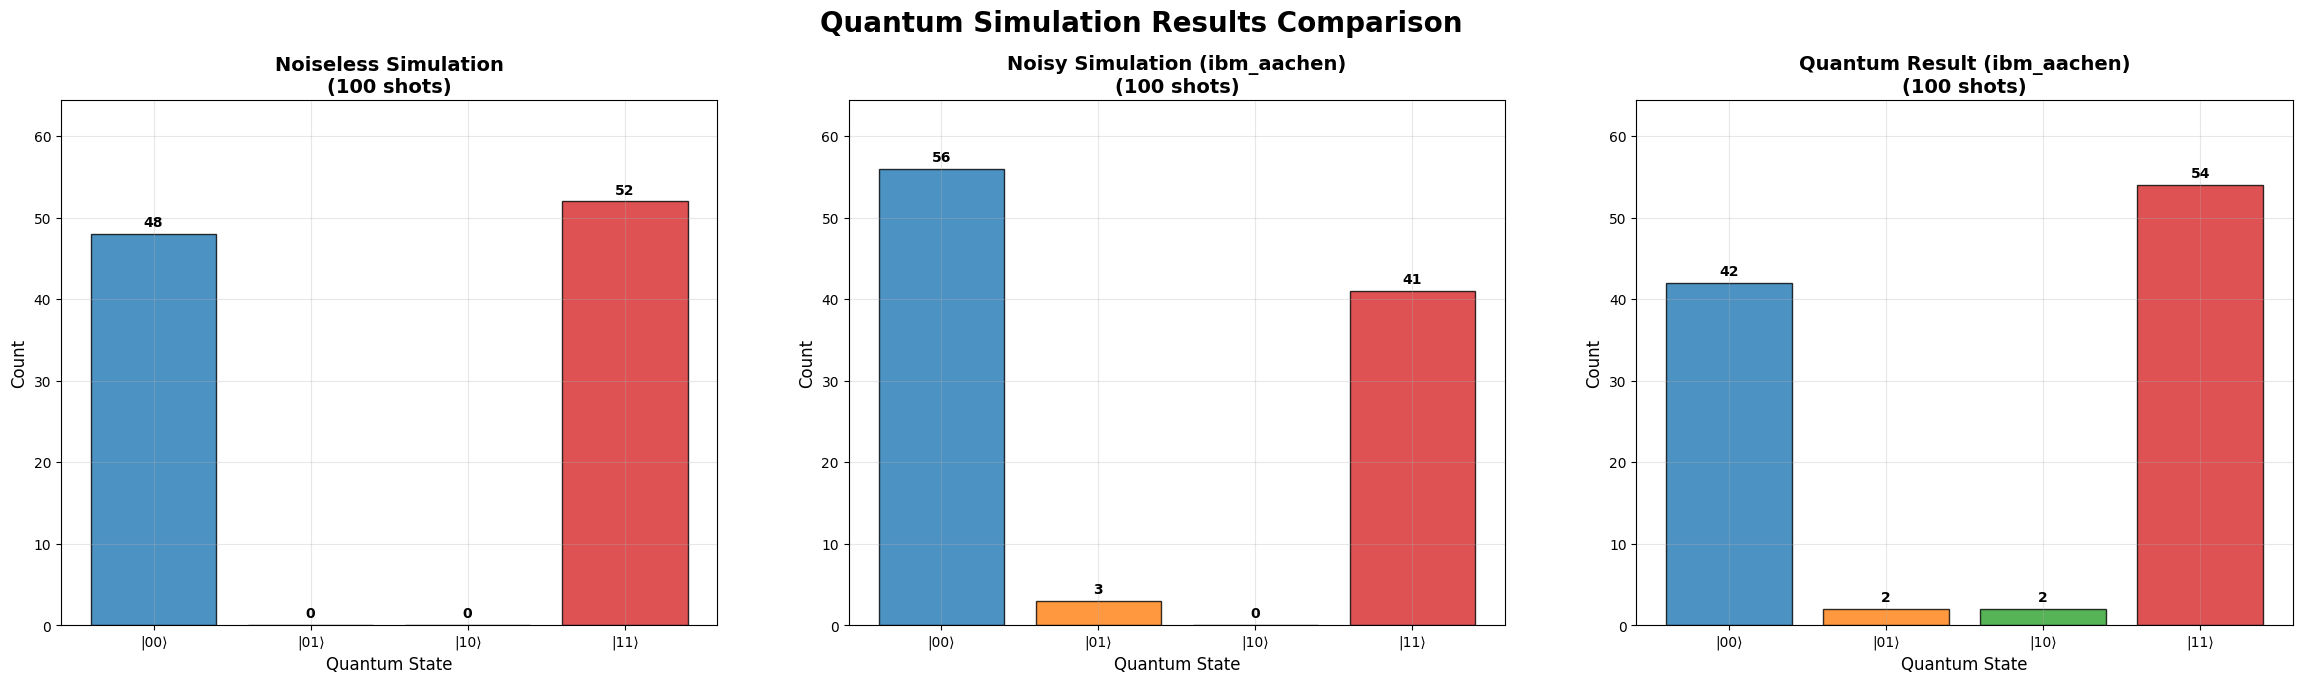

In [ ]:
# 7. Comparison and Plotting of Results
print("\n✅ Comparison and Plotting of Results")
data = {}
for name, fname in [('noiseless', 'noiseless_result.pkl'),
                     ('noisy', 'noisy_result.pkl'),
                     ('quantum', 'quantum_result.pkl')]:
    with open(fname, 'rb') as f:
        data[name] = pickle.load(f)

states = ['00', '01', '10', '11']
comparison_df = pd.DataFrame({
    'State': states,
    'Noiseless': [data['noiseless'].get(s, 0) for s in states],
    'Noisy': [data['noisy'].get(s, 0) for s in states],
    'Quantum': [data['quantum'].get(s, 0) for s in states]
})

print(comparison_df.to_string(index=False))
print("="*50 + "\n")

# Plotting
fig = plt.figure(figsize=(24, 7))
fig.suptitle('Quantum Simulation Results Comparison', fontsize=20, fontweight='bold', y=0.98)

state_labels = ['|00⟩', '|01⟩', '|10⟩', '|11⟩']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
plot_configs = [
    (1, 'Noiseless', f'Noiseless Simulation\n({shots} shots)'),
    (2, 'Noisy', f'Noisy Simulation ({backend.name})\n({shots} shots)'),
    (3, 'Quantum', f'Quantum Result ({backend.name})\n({shots} shots)')
]

max_count = comparison_df[['Noiseless', 'Noisy', 'Quantum']].max().max()

for idx, col, title in plot_configs:
    ax = plt.subplot(1, 3, idx)
    bars = ax.bar(state_labels, comparison_df[col], color=colors, alpha=0.8, edgecolor='black')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Count', fontsize=12)
    ax.set_xlabel('Quantum State', fontsize=12)
    ax.set_ylim(0, max_count * 1.15)
    ax.grid(True, alpha=0.3)
    for bar, count in zip(bars, comparison_df[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max_count*0.01,
                f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.subplots_adjust(left=0.05, bottom=0.1, right=0.98, top=0.85, wspace=0.2)
plt.show()